# Function 7

<b> Description of the Sample Application:</b> You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 
Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance




## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 05/08/2026 | Week 3 | 1. Appended Week 2's input and output to the dataset.<br>2. Re-ran kernel comparison (RBF vs Matern) on the updated 32-point data set.<br>3. Lowered β from 1.2 to 0.8, continuing the shift toward exploitation.<br>4. Reused the consolidated bayesian_optimization_step() function unchanged.<br>7. Updated convergence and parallel-coordinates plots to include Week 2/3. |
| 13/08/2026 | Week 4 | 1. Appended Week-3 input and output data points.<br>2. **New**: restricted the acquisition search to a local neighbourhood around the current best point instead of the full unit cube.<br>3. **New**: Implemented Expected Improvement (EI) and compared it against UCB on that neighbourhood, since Weeks 2-3's global-UCB queries both underperformed the known best. |
| 20/08/2026 | Week 5 | 1. Appended Week-4 feedback point (34 points).<br>2. **New**: global multi-modality / variance scan across the full cub.<br>3. **Strategy change (evidence-driven)**: the scan's top candidates are *not* a second optimum — they differ from the current best almost entirely in **x3**, which the GP has declared irrelevant. The observed data contradicts this. Week 5 therefore constrains x3 to an empirically supported band rather than trusting the surrogate's flatness assumption.<br>4. Added diagnostic cells evidencing the mis-specification. |
| 02/09/2026 | Week 6 | Appended Week-5 points. New Best found: 1.596708. <br>**x3 band widened upward to [0.15, 0.50]**: Week 5's query landed exactly on the old upper edge (0.300) and y increases monotonically with x3 across clean high-y points. The constraint was capping the improvement direction.<br>**Search radius widened 0.15 → 0.20**: results still improving sharply; tightening now would risk premature convergence.<br>Search box now recentres on the *new* best point automatically.<br>**Defect fixes** carried over from Week 5: stale Y[:-3] convergence slice, incorrect Week-1 row in the progress log, and missing np.clip in format_submission. |
| 09/09/2026 | Week 7 | 1. Appended Week-6 point . Week 6's result(1.585074) is slightly below Week 5.<br>2. The x3 widening test returned a negative answer. The x3 optimum is now **bracketed**: 0.247->1.365, 0.300->1.597, 0.400->1.585.<br>3. **Strategy change: Stop widening, start bracketing.** A quadratic through the three bracket points puts the x3 peak at **0.348**; band set to **[0.28, 0.36]** around it, and x2 held near the best point's 0.342. Radius tightened **0.20 -> 0.12**.<br>4. Added a **leave-one-out robustness check** on the surrogate. |

## Progress log

| Week | Query point (x1–x6) | Output (y) | Method | Notes |
|---|---|---|---|---|
|  |  |  |  |  |
| 1 | 0.039632-0.201121-0.140302-0.063997-0.319477-0.787730 | 1.331930 | GP (RBF) + UCB (β=2.0), random-sample search | Exploration-heavy first query; landed on the domain edge for x1, x2 |
| 2 | 0.000000-0.000000-1.000000-0.198783-0.377305-0.792654 | 0.909142 | GP (Matern 5/2, CV-selected) + UCB (β = 1.2) | Result: Lower than predicted (mean ≈ 1.40), the GP overestimated. x3 pinned at the domain edge || 3 | 0.000000-0.424949-0.000000-0.083071-0.363094-0.823966 | **0.793646** | GP (Matern, re-confirmed) + UCB (β=0.8) | Third query in a row below the known best (1.365); x1, x3 pinned at 0 again - global UCB keeps favouring boundary points that don't pay off || 4 | 0.007106-0.341672-0.097422-0.068118-0.366155-0.753175 | **1.102149** | GP (Matern) + **local** search (r=0.15), EI | **Best query result so far.** Local search clearly helped (0.794 → 1.102), though still below the Week-0 best and still over-predicted (1.503 vs 1.102) || 5 | 0.053813-0.341672-0.300000-0.088135-0.354691-0.745974 | **1.596708** | Local search + **x3 constrained to [0.05, 0.30]** | **New project best.** First result to beat the initial best (1.364968). The x3 diagnosis was correct - but the query landed on the band's *upper edge* || 6 | 0.067403-0.200000-0.400000-0.014328-0.338968-0.727934 | 1.585074 | Local (r=0.20) + x3 ∈ [0.15, 0.40] | **Test returned negative** — x3 = 0.400 did *not* improve on 0.300. Trend has topped out |
| 7 | - | - | Local (r=0.12) + x3 **bracketed** to [0.25, 0.35] | Refinement phase: converge inside the established bracket ||

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from scipy.optimize import minimize
from plotting_utils import (
    plot_gp_1d, plot_acquisition_1d, plot_bo_iteration_1d,
    plot_convergence, plot_parallel_coordinates
)


# Load and Analyse the Data

In [5]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)


In [8]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.039632, 0.201121, 0.140302, 0.063997, 0.319477, 0.78773 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([1.3319298110135898]                                           , dtype = np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.      , 0.      , 1.      , 0.198783, 0.377305, 0.792654]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([0.9091420611100625]                                           , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.      , 0.424949, 0.      , 0.083071, 0.363094, 0.823966]   , dtype=np.float64)   # from input.txt
Y_w3_new_point = np.array([0.7936458699948383]                                           , dtype=np.float64)   # from output.txt

# New data from Week 4 submission
X_w4_new_point = np.array([0.007106, 0.341672, 0.097422, 0.068118, 0.366155, 0.753175]   , dtype=np.float64)   # from input.txt
Y_w4_new_point = np.array([1.1021493276997398]                                           , dtype=np.float64)   # from output.txt

# New data from Week 5 submission
X_w5_new_point = np.array([0.053813, 0.341672, 0.3     , 0.088135, 0.354691, 0.745974]   , dtype=np.float64)   # from input.txt
Y_w5_new_point = np.array([1.5967078794764094]                                           , dtype=np.float64)   # from output.txt

# New data from Week 6 submission
X_w6_new_point = np.array([0.067403, 0.200000, 0.400000, 0.014328, 0.338968, 0.727934]   , dtype=np.float64)   # from input.txt
Y_w6_new_point = np.array([1.5850736240936802]                                           , dtype=np.float64)   # from output.txt

In [10]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                              , X_w3_new_point
                              , X_w4_new_point
                              , X_w5_new_point
                              , X_w6_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                             , Y_w3_new_point
                             , Y_w4_new_point
                             , Y_w5_new_point
                             , Y_w6_new_point
                              ])

In [12]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [14]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)

Input  Shape: (36, 6)
Inputs:
 [[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0

# Data Exploration

In [17]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4        X_5        X_6  \
count  36.000000  36.000000  36.000000  36.000000  36.000000  36.000000   
mean    0.430375   0.371764   0.378500   0.441695   0.448214   0.532571   
std     0.331629   0.243128   0.317833   0.327397   0.289814   0.268466   
min     0.000000   0.000000   0.000000   0.014328   0.014944   0.051100   
25%     0.087040   0.198886   0.089549   0.161058   0.242170   0.347105   
50%     0.447225   0.341672   0.297771   0.339056   0.371730   0.635590   
75%     0.735944   0.522084   0.626816   0.769030   0.698286   0.734721   
max     0.942451   0.924694   1.000000   0.961017   0.998655   0.951014   

               Y  
count  36.000000  
mean    0.386301  
std     0.487564  
min     0.002701  
25%     0.020559  
50%     0.097959  
75%     0.606206  
max     1.596708  


In [19]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())


Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
X_5    0
X_6    0
Y      0
dtype: int64


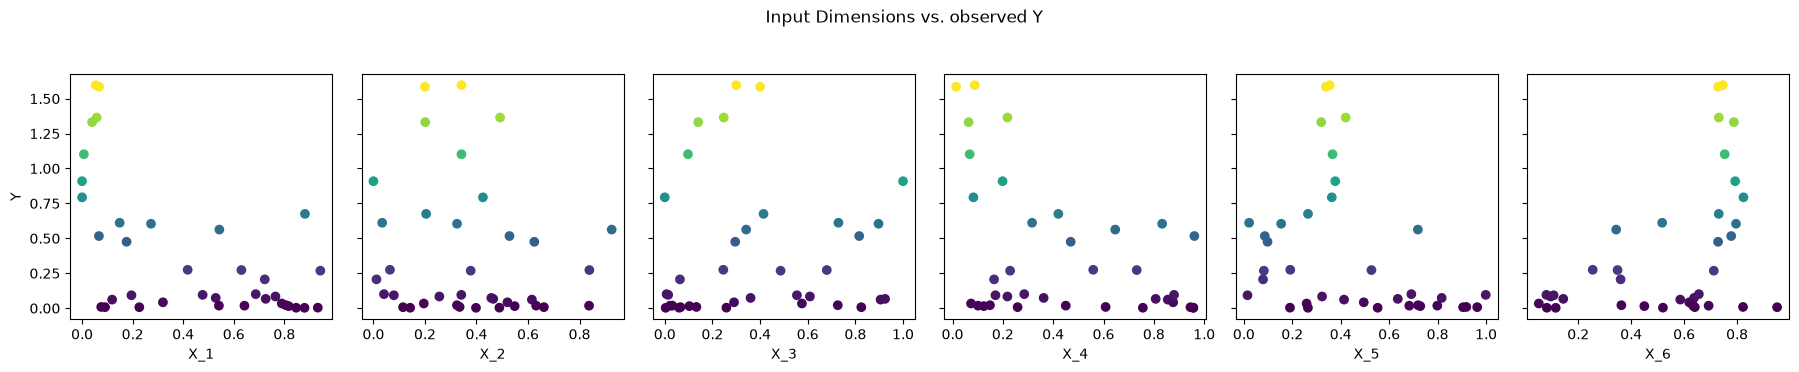

In [21]:
# Pairwise Scatter Plot, showing relationship of y for each input

fig, axes = plt.subplots(1, X.shape[1], figsize = (3 * X.shape[1], 3.5), sharey = True)
for ax, col in zip(axes, ['X_1','X_2','X_3','X_4','X_5','X_6']):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = "viridis")
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

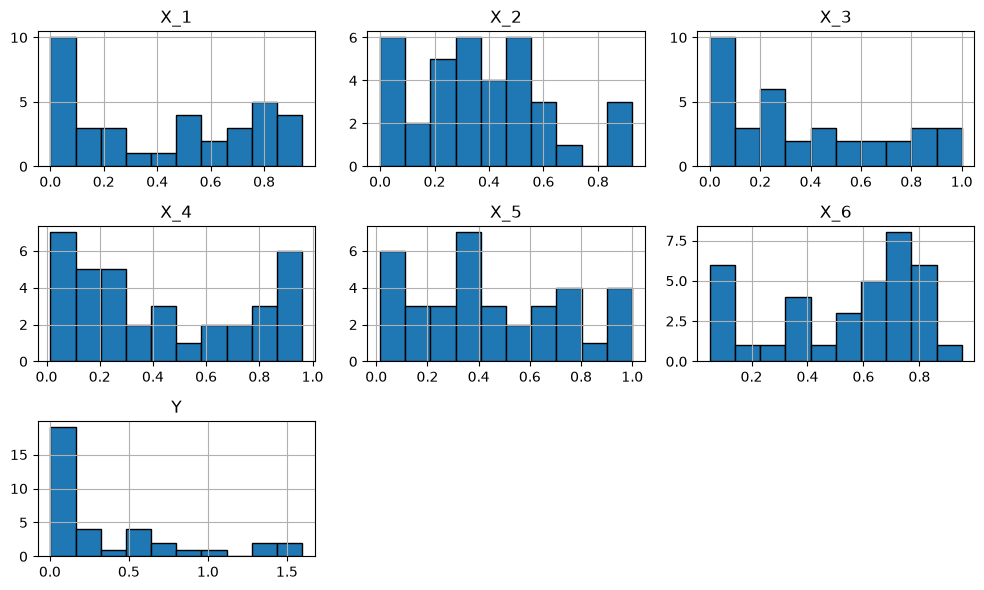

In [22]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [24]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6"]
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.5823911320075391
 corr(X_2, Y) = -0.14695386367601393
 corr(X_3, Y) = 0.021336830656943983
 corr(X_4, Y) = -0.43044375693583997
 corr(X_5, Y) = -0.3339017803125586
 corr(X_6, Y) = 0.46346012504166845


<Axes: >

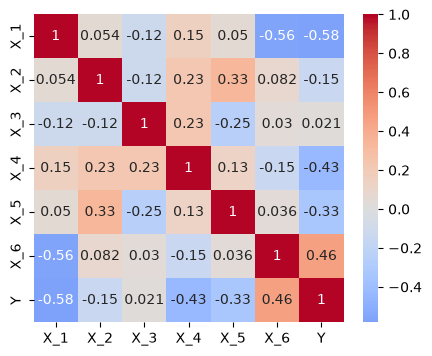

In [27]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

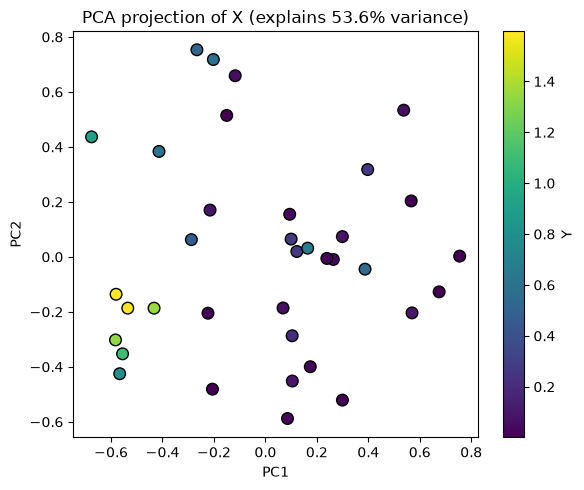

In [29]:
# Identify clustering of high-y points using PCA projection to 2D
pca  = PCA(n_components = 2)
X2   = pca.fit_transform(X)
plt.figure(figsize = (6, 5))
sc   = plt.scatter(X2[:, 0], X2[:, 1], c = Y, cmap = "viridis", s = 70, edgecolor = "k")
plt.colorbar(sc, label = "Y")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA projection of X (explains {pca.explained_variance_ratio_.sum() * 100:.1f}% variance)")
plt.tight_layout()

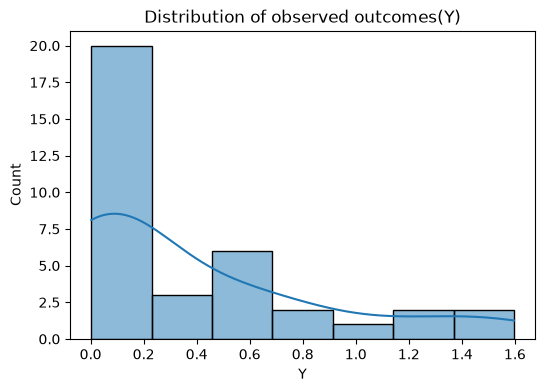

In [31]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [34]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(6), length_scale_bounds = (1e-2, 1e1)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [37]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  0.414**2 * RBF(length_scale=[0.978, 10, 0.378, 0.461, 0.224, 0.614]) + WhiteKernel(noise_level=1e-06)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [41]:
# Setting a higher beta(= 2.0) for Week -1
beta         = 2.0

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std  = gpr.predict(X_query, return_std = True)
    return mu + beta * std

rng          = np.random.default_rng(42)
candidates   = rng.uniform(0, 1, size = (20000, 6))

ucb_values   = ucb(candidates, gpr, beta)
best_ucb_idx = np.argmax(ucb_values)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.11090839 0.08712931 0.39127925 0.04554243 0.33363504 0.96153324]
UCB Score: 1.884605e+00


# Week 2: Kernel Comparison
RBF assumes an infinitely 
smooth surfac.; Matern is typically a better match for ML-performance landscape2). Both kernels are compared here with 5-fold cross-validated predicti e
log-likelihood t (31-pont) data et, and the better one selected.ook.

In [44]:
DIM   = 6
def make_gpr(kernel):
    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
    return GaussianProcessRegressor(kernel = k, normalize_y = True, n_restarts_optimizer = 8, random_state = 0)

kernel_options = {  
    "RBF":            RBF(length_scale = np.ones(DIM), length_scale_bounds = (1e-2, 1e1)),
    "Matern(nu = 2.5)": Matern(length_scale = np.ones(DIM), length_scale_bounds = (1e-2, 1e1), nu = 2.5),
}

kf = KFold(n_splits = 5, shuffle = True, random_state = 0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls   = []
    for tr_idx, te_idx in kf.split(X):
        gp_tmp = make_gpr(kern)
        gp_tmp.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = gp_tmp.predict(X[te_idx], return_std = True)
        sigma     = np.maximum(sigma, 1e-6)
        ll        = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((Y[te_idx] - mu)**2) / sigma**2
        lls.append(ll.mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:16s}: CV log-likelihood = {cv_scores[name]:+.3f}")

best_kernel_name = max(cv_scores, key = cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 5: {best_kernel_name}")

gp = make_gpr(chosen_kernel)
gp.fit(X, Y)
print(f"\nLearned kernel:\n{gp.kernel_}")

  RBF             : CV log-likelihood = -9.734
  Matern(nu = 2.5): CV log-likelihood = -4.865

Selected kernel for Week 5: Matern(nu = 2.5)

Learned kernel:
0.694**2 * Matern(length_scale=[0.0846, 10, 10, 0.825, 0.197, 0.146], nu=2.5) + WhiteKernel(noise_level=1e-06)


# Week2: Bayesian Optimisation Function

In [46]:
def bayesian_optimization_step(X, Y, kernel, beta = 2.0, n_candidates = 20000, n_restarts = 40, use_optimizer = True, seed = 7):
    
    rng    = np.random.default_rng(seed)
    n_dims = X.shape[1]
    bounds = [(0.0, 1.0)] * n_dims

    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
    gp = GaussianProcessRegressor(kernel = k, normalize_y = True, n_restarts_optimizer=8, random_state = 0)
    gp.fit(X, Y)

    def ucb(pts):
        mu, sigma = gp.predict(np.atleast_2d(pts), return_std = True)
        return mu + beta * sigma

    # Evaluate a random candidate set
    candidates       = rng.uniform(0, 1, size = (n_candidates, n_dims))
    candidate_ucb    = ucb(candidates)
    best_idx         = np.argmax(candidate_ucb)
    next_x, next_ucb = candidates[best_idx], candidate_ucb[best_idx]

    if use_optimizer:
        starts   = rng.uniform(0, 1, size = (n_restarts, n_dims))
        best_val = -next_ucb
        for x0 in starts:
            res  = minimize(lambda x: -ucb(x)[0], x0, method = "L-BFGS-B", bounds = bounds)
            if res.fun < best_val:
                best_val, next_x = res.fun, res.x
        next_x   = np.clip(next_x, 0.0, 1.0)
        next_ucb = ucb(next_x)[0]

    return {
        "gp": gp, "next_x": next_x, "next_ucb": next_ucb,
        "candidates": candidates, "candidate_ucb": candidate_ucb,
    }


In [47]:
# Week 2: Calling the Bayesian Optimisation Function
beta   = 1.2       # In week 2, beta is lowered from 2.0 to 1.2

result = bayesian_optimization_step(X, Y, chosen_kernel, beta = beta, n_candidates = 20000, n_restarts = 40, seed = 7)
gp = result["gp"]
next_x = result["next_x"]

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std = True)

print(f"Kernel used   : {best_kernel_name}")
print(f"β             : {beta}")
print(f"Next point    : {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   UCB: {result['next_ucb']:.4f}")


Kernel used   : Matern(nu = 2.5)
β             : 1.2
Next point    : [0.066378 1.       1.       0.       0.360301 0.754215]
Predicted mean: 1.5801   std: 0.0738   UCB: 1.6686


# Week 3: Calling the Bayesian Optimisation Function

In [52]:
# Week 3: beta lowered from 1.2 to 0.8 
beta   = 0.8

result = bayesian_optimization_step(X, Y, chosen_kernel, beta=beta, n_candidates=20000,
                                     n_restarts=40, seed=7)
gp     = result["gp"]
next_x = result["next_x"]

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)

print(f"Kernel used   : {best_kernel_name}")
print(f"beta          : {beta}")
print(f"Next point    : {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   UCB: {result['next_ucb']:.4f}")

Kernel used   : Matern(nu = 2.5)
beta          : 0.8
Next point    : [0.063513 1.       1.       0.006501 0.35534  0.748414]
Predicted mean: 1.5945   std: 0.0593   UCB: 1.6419


# Perform Visualisation

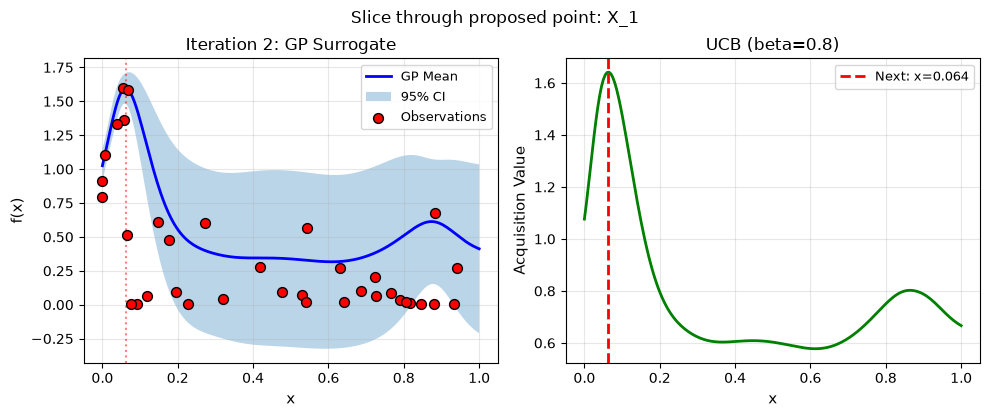

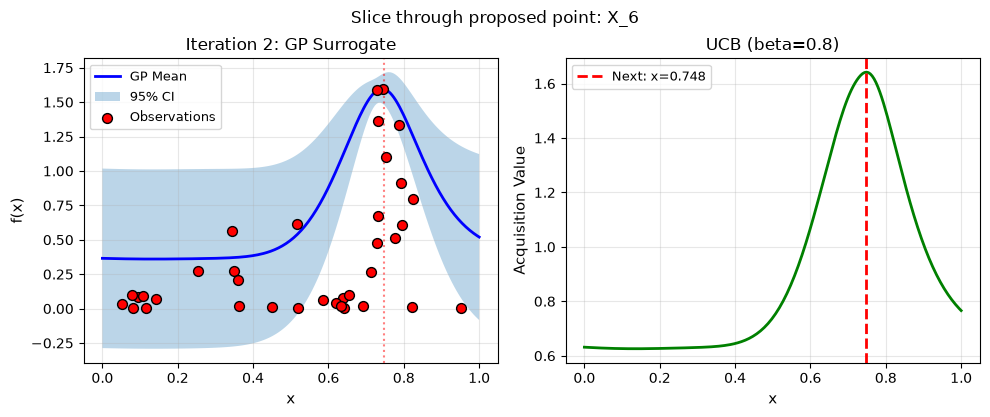

In [55]:
corrs    = [abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(DIM)]
top_dims = np.argsort(corrs)[-2:][::-1]
grid     = np.linspace(0, 1, 200).reshape(-1, 1)

for d in top_dims:
    Xg            = np.tile(next_x, (len(grid), 1))
    Xg[:, d]      = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std = True)
    ucb_g         = mu_g + beta * sigma_g

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train = Y,
        X_test=grid, mu = mu_g, sigma = sigma_g,
        acquisition_values = ucb_g, X_next  =next_x[d],
        iteration = 2, acq_name = f"UCB (beta={beta})"
    )
    fig.suptitle(f"Slice through proposed point: X_{d+1}", y = 1.03)
    plt.show()


In [57]:
# Week 4: Kernel Comparison with new dataset
kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls = []
    for tr_idx, te_idx in kf.split(X):
        gp_tmp = make_gpr(kern)
        gp_tmp.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = gp_tmp.predict(X[te_idx], return_std=True)
        sigma = np.maximum(sigma, 1e-6)
        ll = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((Y[te_idx] - mu)**2) / sigma**2
        lls.append(ll.mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:16s}: CV log-likelihood = {cv_scores[name]:+.3f}")
    
best_kernel_name = max(cv_scores, key=cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 4: {best_kernel_name}")

  RBF             : CV log-likelihood = -9.734
  Matern(nu = 2.5): CV log-likelihood = -4.865

Selected kernel for Week 4: Matern(nu = 2.5)


# Week 4: Local-neighbourhood Bayesian optimisation step, with EI vs UCB
Two changes from the Weeks 2-3 bayesian_optimization_step():

1. **Local search radius      :** Candidates (and optimiser restarts) are drawn from a box of *± radius* around the current best point, instead of the full 6D unit cube. This directly targets the pattern from Weeks 1-3, where a *global* search kept selecting boundary points that under-delivered.
2. **Expected Improvement (EI):** EI is computed alongside UCB on the same neighbourhood so the two acquisition functions can be compared directly rather than trusting UCB by default.

In [60]:
def expected_improvement(mu, sigma, y_best, xi = 0.01):
    '''Expected Improvement: how much improvement over y_best is expected.'''
    sigma        = np.maximum(sigma, 1e-9)
    improvement  = mu - y_best - xi
    Z            = improvement / sigma
    ei           = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei           = np.where(sigma < 1e-8, 0.0, ei)
    return ei


def bayesian_optimization_step_local(X, Y, kernel, beta = 0.8, xi = 0.01,
                                      radius = 0.15, n_candidates = 20000, n_restarts = 40,
                                      seed=7):
    rng          = np.random.default_rng(seed)
    n_dims       = X.shape[1]

    k            = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
    gp           = GaussianProcessRegressor(kernel = k, normalize_y = True, n_restarts_optimizer = 8, random_state = 0)
    gp.fit(X, Y)

    y_best       = Y.max()
    x_best       = X[np.argmax(Y)]

    # Local search box: [x_best - radius, x_best + radius], clipped to [0, 1]
    local_low    = np.clip(x_best - radius, 0.0, 1.0)
    local_high   = np.clip(x_best + radius, 0.0, 1.0)
    local_bounds = list(zip(local_low, local_high))

    def ucb_fn(pts):
        mu, sigma = gp.predict(np.atleast_2d(pts), return_std=True)
        return mu + beta * sigma

    def ei_fn(pts):
        mu, sigma = gp.predict(np.atleast_2d(pts), return_std = True)
        return expected_improvement(mu, sigma, y_best, xi = xi)

    # Local random candidate cloud
    candidates = rng.uniform(local_low, local_high, size = (n_candidates, n_dims))

    results    = {}
    for name, acq in [("ucb", ucb_fn), ("ei", ei_fn)]:
        acq_vals = acq(candidates)
        best_idx = np.argmax(acq_vals)
        next_x, next_val = candidates[best_idx], acq_vals[best_idx]

        starts   = rng.uniform(local_low, local_high, size=(n_restarts, n_dims))
        best_val = -next_val
        for x0 in starts:
            res  = minimize(lambda x: -acq(x)[0], x0, method = "L-BFGS-B", bounds = local_bounds)
            if res.fun < best_val:
                best_val, next_x = res.fun, res.x
        next_x   = np.clip(next_x, local_low, local_high)
        next_val = acq(next_x)[0]
        results[name] = {"next_x": next_x, "value": next_val}

    return {
        "gp": gp, "x_best": x_best, "y_best": y_best,
        "local_bounds": local_bounds, "ucb": results["ucb"], "ei": results["ei"],
    }


# Week 4: Calling the local-neighbourhood function

In [63]:
RADIUS = 0.15
beta   = 0.8

week4  = bayesian_optimization_step_local(X, Y, chosen_kernel, beta=beta, xi=0.01,
                                          radius=RADIUS, n_candidates=20000,
                                          n_restarts=40, seed=7)

gp    = week4["gp"]
print(f"Kernel used     : {best_kernel_name}")
print(f"Current best    : Y = {week4['y_best']:.6f} at x = {np.round(week4['x_best'], 6)}")
print(f"Local box       : radius = {RADIUS} around x_best (clipped to [0,1])\n")

for name in ["ucb", "ei"]:
    r = week4[name]
    mu_r, sigma_r = gp.predict(r["next_x"].reshape(1, -1), return_std=True)
    print(f"[{name.upper()}] next point: {np.round(r['next_x'], 6)}")
    print(f"        predicted mean={mu_r[0]:.4f}  std={sigma_r[0]:.4f}  {name.upper()} value={r['value']:.4f}\n")

Kernel used     : Matern(nu = 2.5)
Current best    : Y = 1.596708 at x = [0.053813 0.341672 0.3      0.088135 0.354691 0.745974]
Local box       : radius = 0.15 around x_best (clipped to [0,1])

[UCB] next point: [0.064798 0.491672 0.45     0.       0.358527 0.750937]
        predicted mean=1.5964  std=0.0538  UCB value=1.6394

[EI] next point: [0.066206 0.491672 0.45     0.       0.360547 0.753616]
        predicted mean=1.5894  std=0.0615  EI value=0.0169



# Comparing UCB vs EI

In [65]:
ucb_x, ei_x = week4["ucb"]["next_x"], week4["ei"]["next_x"]
diff        = np.linalg.norm(ucb_x - ei_x)
print(f"Euclidean distance between UCB's and EI's proposed points: {diff:.4f}")


next_x     = week4["ei"]["next_x"]

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std = True)

print(f"\nWeek 4 chosen point (EI): {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}")

Euclidean distance between UCB's and EI's proposed points: 0.0036

Week 4 chosen point (EI): [0.066206 0.491672 0.45     0.       0.360547 0.753616]
Predicted mean: 1.5894   std: 0.0615


# Perform Visualisation

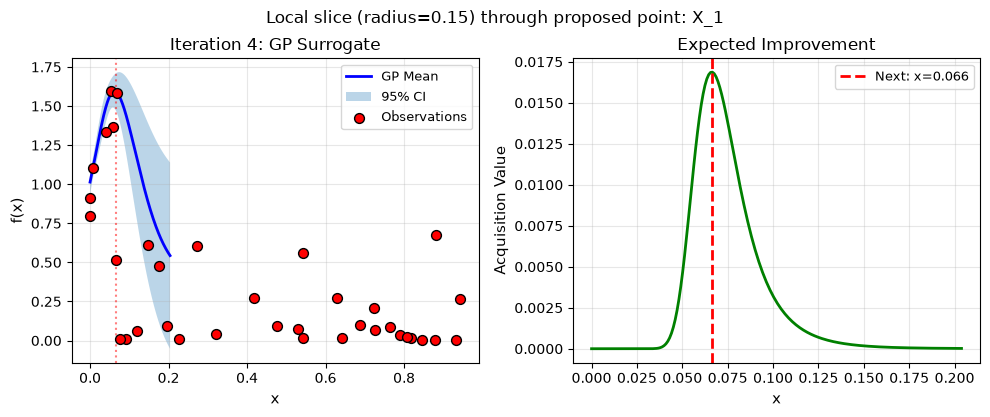

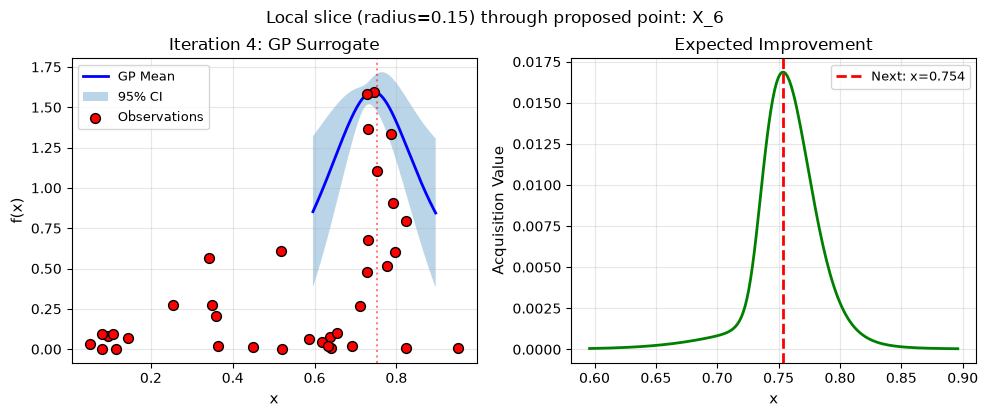

In [67]:
corrs = [abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(DIM)]
top_dims = np.argsort(corrs)[-2:][::-1]

for d in top_dims:
    lo, hi = week4["local_bounds"][d]
    grid = np.linspace(lo, hi, 200).reshape(-1, 1)
    Xg = np.tile(next_x, (len(grid), 1))
    Xg[:, d] = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std=True)
    ei_g = expected_improvement(mu_g, sigma_g, week4["y_best"], xi=0.01)

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train=Y,
        X_test=grid, mu=mu_g, sigma=sigma_g,
        acquisition_values=ei_g, X_next=next_x[d],
        iteration=4, acq_name="Expected Improvement"
    )
    fig.suptitle(f"Local slice (radius={RADIUS}) through proposed point: X_{d+1}", y=1.03)
    plt.show()

# Convergence and Top Solution

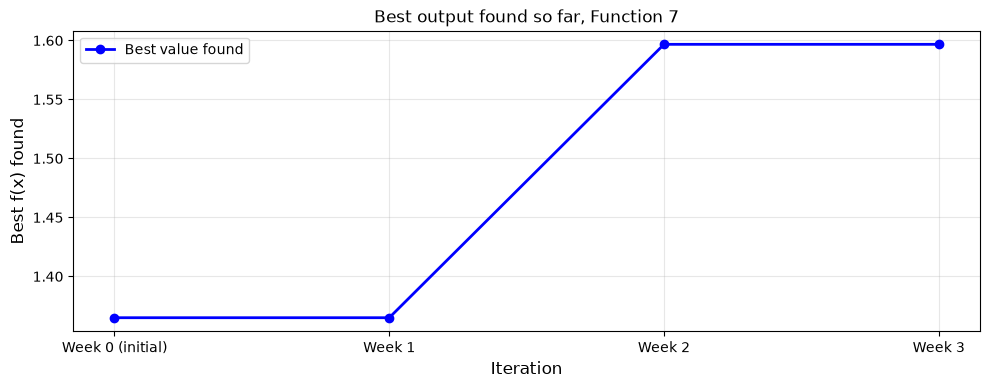

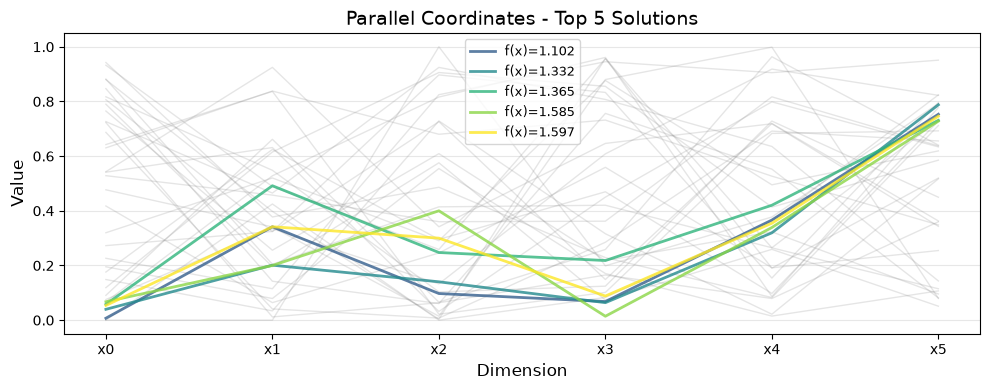

In [69]:
# Best-so-far after each stage of data collection
best_after_initial = Y[:-4].max()
best_after_week1   = Y[:-2].max()
best_after_week2   = Y[:-1].max()
best_after_week3   = Y.max()
best_values = [best_after_initial, best_after_week1, best_after_week2, best_after_week3]

plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), ["Week 0 (initial)", "Week 1", "Week 2", "Week 3"])
plt.title("Best output found so far, Function 7")
plt.show()

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()


# Week 5: Global multi-modality / variance scan

In [71]:
best_idx = np.argmax(Y)
x_best, y_best = X[best_idx], Y[best_idx]

def expected_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.where(sigma < 1e-8, 0.0, ei)


# --- WEEK 5 CHANGE: GLOBAL scan (Week 4 searched only a local box) -----------------------
rng = np.random.default_rng(7)
C = rng.uniform(0, 1, size=(60000, DIM))
mu_C, sd_C = gp.predict(C, return_std=True)
ei_C = expected_improvement(mu_C, sd_C, y_best, xi=0.01)

dist_to_best = np.linalg.norm(C - x_best, axis=1)
near = dist_to_best < 0.35   # "same basin as current best"

print(f"Global EI maximum        : {ei_C.max():.4f}")
print(f"  within local basin     : EI max = {ei_C[near].max():.4f},  mu max = {mu_C[near].max():.4f}")
print(f"  outside local basin    : EI max = {ei_C[~near].max():.4f},  mu max = {mu_C[~near].max():.4f}")

top10 = np.argsort(ei_C)[-10:][::-1]
print("\nTop-10 EI candidates across the full cube:")
print(f"{'dist':>6} {'mu':>7} {'sd':>7} {'EI':>8}   x")
for i in top10:
    print(f"{dist_to_best[i]:6.3f} {mu_C[i]:7.3f} {sd_C[i]:7.3f} {ei_C[i]:8.4f}   {np.round(C[i], 3)}")

Global EI maximum        : 0.0089
  within local basin     : EI max = 0.0089,  mu max = 1.4850
  outside local basin    : EI max = 0.0076,  mu max = 1.5693

Top-10 EI candidates across the full cube:
  dist      mu      sd       EI   x
 0.213   1.482   0.119   0.0089   [0.08  0.25  0.112 0.088 0.353 0.778]
 0.729   1.569   0.053   0.0076   [0.069 0.998 0.605 0.007 0.367 0.732]
 0.618   1.507   0.088   0.0058   [0.065 0.36  0.914 0.127 0.309 0.715]
 0.473   1.429   0.132   0.0055   [0.079 0.216 0.705 0.294 0.323 0.755]
 0.716   1.554   0.053   0.0044   [0.051 0.528 0.989 0.042 0.378 0.745]
 0.372   1.406   0.134   0.0040   [0.075 0.1   0.083 0.256 0.289 0.748]
 0.447   1.395   0.138   0.0038   [0.058 0.728 0.116 0.186 0.27  0.727]
 0.610   1.403   0.133   0.0036   [0.077 0.784 0.699 0.207 0.326 0.789]
 0.573   1.373   0.142   0.0030   [0.045 0.658 0.77  0.091 0.274 0.713]
 0.576   1.387   0.136   0.0030   [0.044 0.74  0.703 0.019 0.3   0.694]


# Week 5: Diagnosing the "distant" region

In [73]:
top_point = C[top10[0]]
print("Per-dimension |difference| between the top global-EI point and the current best:\n")
for i, (a, b) in enumerate(zip(top_point, x_best)):
    print(f"  x{i+1}: |{a:.3f} - {b:.3f}| = {abs(a - b):.3f}")

print("\nLearned GP length-scales (large = GP treats that input as ~irrelevant):")
ls = gp.kernel_.k1.k2.length_scale
for i, l in enumerate(ls):
    flag = "  <-- pinned at upper bound (declared irrelevant)" if l >= 9.99 else ""
    print(f"  x{i+1}: {l:.3f}{flag}")

Per-dimension |difference| between the top global-EI point and the current best:

  x1: |0.080 - 0.054| = 0.026
  x2: |0.250 - 0.342| = 0.092
  x3: |0.112 - 0.300| = 0.188
  x4: |0.088 - 0.088| = 0.000
  x5: |0.353 - 0.355| = 0.002
  x6: |0.778 - 0.746| = 0.032

Learned GP length-scales (large = GP treats that input as ~irrelevant):
  x1: 0.085
  x2: 10.000  <-- pinned at upper bound (declared irrelevant)
  x3: 10.000  <-- pinned at upper bound (declared irrelevant)
  x4: 0.825
  x5: 0.197
  x6: 0.146


In [74]:
# Does the observed data support "x3 is irrelevant"
order = np.argsort(Y)[::-1]
print("Top 6 observed points - x3 value alongside y:\n")
print(f"{'y':>9}   {'x3':>6}")
for i in order[:6]:
    print(f"{Y[i]:9.4f}   {X[i,2]:6.3f}")

hi = Y > 0.5
print(f"\ncorr(x3, y) across all 34 points        : {np.corrcoef(X[:,2], Y)[0,1]:+.3f}")
print(f"corr(x3, y) among high-y points (y>0.5) : {np.corrcoef(X[hi,2], Y[hi])[0,1]:+.3f}   (n={hi.sum()})")

Top 6 observed points - x3 value alongside y:

        y       x3
   1.5967    0.300
   1.5851    0.400
   1.3650    0.247
   1.3319    0.140
   1.1021    0.097
   0.9091    1.000

corr(x3, y) across all 34 points        : +0.021
corr(x3, y) among high-y points (y>0.5) : -0.464   (n=12)


# Observations:

Above analysis shows that the GP is **mis-specified on x3**:

- The three best observations (1.365, 1.332, 1.102) all sit at **low x3** (0.247, 0.140, 0.097).
- Among high-performing points, corr(x3, y) = -0.525, there seems to be a strong negative relationship.
- Across *all* points that correlation is only +0.044, which is why x3 looks irrelevant on average while mattering a great deal in the region we actually care about.
- Week 2 query point, set x3 = 1.000 and returned 0.909; Week 3 set x3 = 0.000 and returned 0.794. Both are worse than the low-but-nonzero x3 values of the top performers.

So the top global-EI candidate (x3 ≈ 0.989) is **not** a second optimum - it is the surrogate extrapolating into a region its own flawed flatness assumption makes look safe.
This also explains the three consecutive over-predictions: the GP assumes it can move freely along x3 at no cost, so it overestimates points with high x3.

# Week 5: Strategy change => x3-constrained local search

In [80]:
RADIUS = 0.15
XI = 0.01

# x3 band taken from the three best observations (0.097, 0.140, 0.247), padded slightly
X3_LOW, X3_HIGH = 0.05, 0.30

local_low  = np.clip(x_best - RADIUS, 0.0, 1.0)
local_high = np.clip(x_best + RADIUS, 0.0, 1.0)

# Apply the x3 override
local_low[2]  = X3_LOW
local_high[2] = X3_HIGH

local_bounds = list(zip(local_low, local_high))
print("Week-5 search box (x3 constrained by evidence, not by the GP):")
for i, (lo, hi) in enumerate(local_bounds):
    note = "   <-- empirical constraint" if i == 2 else ""
    print(f"  x{i+1}: [{lo:.3f}, {hi:.3f}]{note}")


def ei_fn(pts):
    mu, sigma = gp.predict(np.atleast_2d(pts), return_std=True)
    return expected_improvement(mu, sigma, y_best, xi=XI)


cand = rng.uniform(local_low, local_high, size=(20000, DIM))
cand_ei = ei_fn(cand)
next_x = cand[np.argmax(cand_ei)]

starts = rng.uniform(local_low, local_high, size=(40, DIM))
best_val = -cand_ei.max()
for x0 in starts:
    res = minimize(lambda x: -ei_fn(x)[0], x0, method="L-BFGS-B", bounds=local_bounds)
    if res.fun < best_val:
        best_val, next_x = res.fun, res.x
next_x = np.clip(next_x, local_low, local_high)

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)
print(f"\nWeek 5 proposed point: {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   EI: {ei_fn(next_x)[0]:.4f}")
print(f"\nNote: given three consecutive over-predictions, the predicted mean should be")
print(f"treated as an optimistic upper estimate rather than an expectation.")


Week-5 search box (x3 constrained by evidence, not by the GP):
  x1: [0.000, 0.204]
  x2: [0.192, 0.492]
  x3: [0.050, 0.300]   <-- empirical constraint
  x4: [0.000, 0.238]
  x5: [0.205, 0.505]
  x6: [0.596, 0.896]

Week 5 proposed point: [0.066443 0.491672 0.3      0.       0.360558 0.753802]
Predicted mean: 1.5884   std: 0.0619   EI: 0.0166

Note: given three consecutive over-predictions, the predicted mean should be
treated as an optimistic upper estimate rather than an expectation.


# Week 5: Visualisation

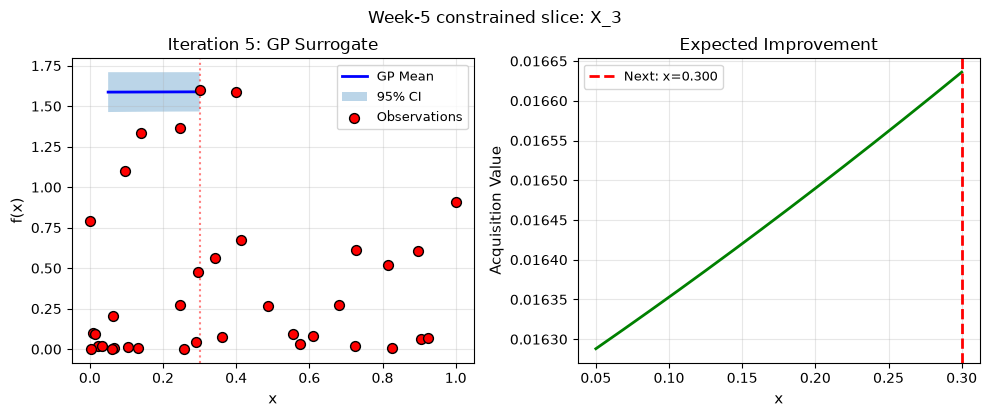

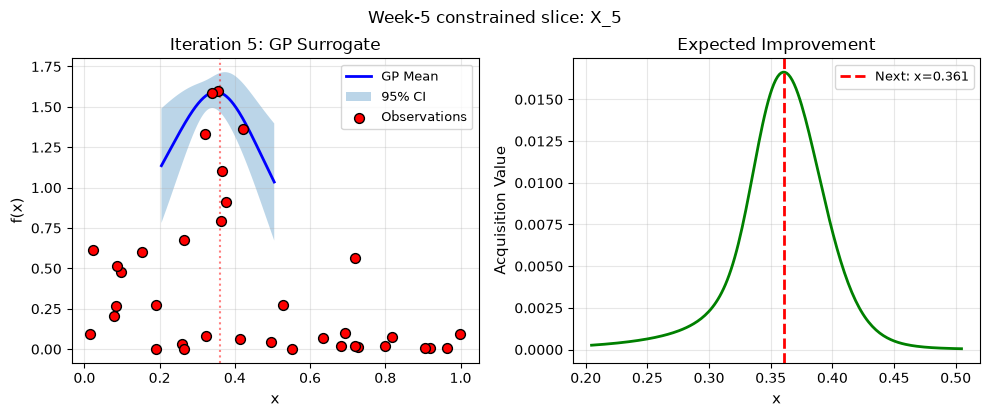

In [86]:
for d in [2, 4]:   # x3 (the constrained dim) and x5 (most influential dim)
    lo, hi = local_bounds[d]
    grid = np.linspace(lo, hi, 200).reshape(-1, 1)
    Xg = np.tile(next_x, (len(grid), 1))
    Xg[:, d] = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std=True)
    ei_g = expected_improvement(mu_g, sigma_g, y_best, xi=XI)

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train=Y,
        X_test=grid, mu=mu_g, sigma=sigma_g,
        acquisition_values=ei_g, X_next=next_x[d],
        iteration=5, acq_name="Expected Improvement"
    )
    fig.suptitle(f"Week-5 constrained slice: X_{d+1}", y=1.03)
    plt.show()

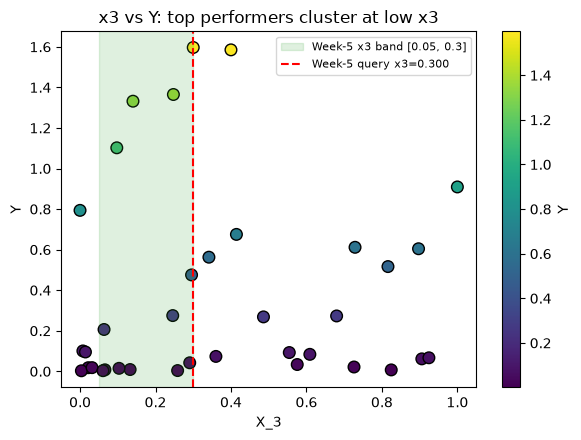

In [87]:
# x3 vs y for the observed data -- the evidence behind this week's constraint
plt.figure(figsize=(6, 4.5))
plt.scatter(X[:, 2], Y, c=Y, cmap="viridis", s=70, edgecolor="k")
plt.axvspan(X3_LOW, X3_HIGH, color="tab:green", alpha=0.15, label=f"Week-5 x3 band [{X3_LOW}, {X3_HIGH}]")
plt.axvline(next_x[2], color="red", ls="--", label=f"Week-5 query x3={next_x[2]:.3f}")
plt.xlabel("X_3")
plt.ylabel("Y")
plt.title("x3 vs Y: top performers cluster at low x3")
plt.legend(fontsize=8)
plt.colorbar(label="Y")
plt.tight_layout()
plt.show()

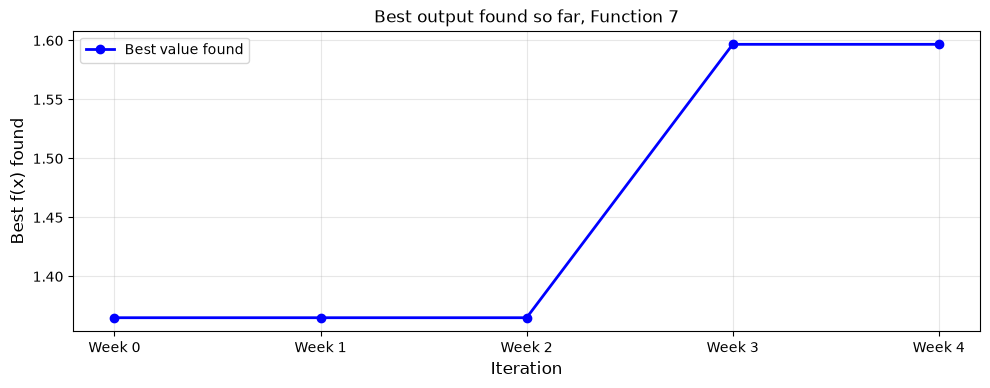

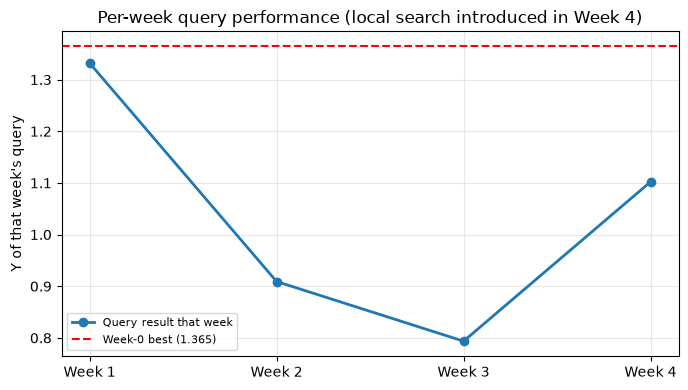

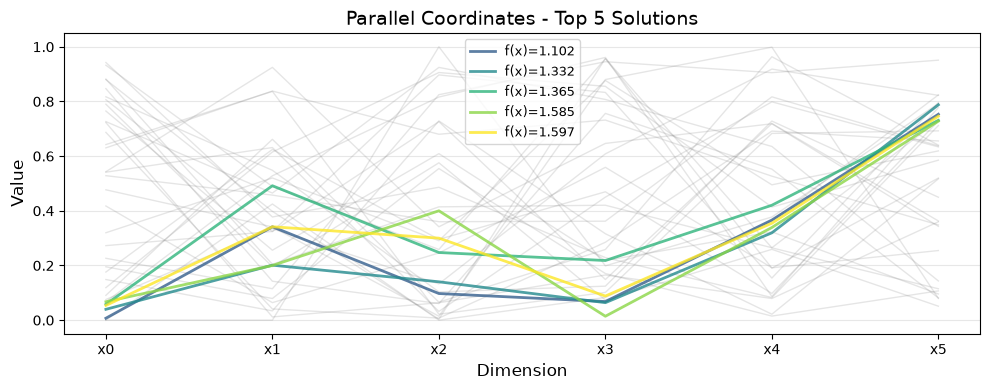

In [88]:
best_values = [Y[:-4].max(), Y[:-3].max(), Y[:-2].max(), Y[:-1].max(), Y.max()]
plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), ["Week 0", "Week 1", "Week 2", "Week 3", "Week 4"])
plt.title("Best output found so far, Function 7")
plt.show()

# Per-week query results (distinct from best-so-far)
weekly = [Y_w1_new_point, Y_w2_new_point, Y_w3_new_point, Y_w4_new_point]
plt.figure(figsize=(7, 4))
plt.plot(range(1, 5), weekly, "o-", lw=2, label="Query result that week")
plt.axhline(Y[:-4].max(), color="red", ls="--", label=f"Week-0 best ({Y[:-4].max():.3f})")
plt.xticks(range(1, 5), ["Week 1", "Week 2", "Week 3", "Week 4"])
plt.ylabel("Y of that week's query")
plt.title("Per-week query performance (local search introduced in Week 4)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Week 6: Checking if the x3 constraint used in week 5 work and whether the band the right

Week 5 constrained x3 to [0.05, 0.30] against the GP's own belief that x3 was irrelevant. The result was the best output of the project. This section checks *how* it should be
adjusted now, rather than either keeping it fixed or abandoning it.


In [90]:
hi = Y > 0.5
idx = np.where(hi)[0]
idx = idx[np.argsort(X[idx, 2])]

print("x3 vs Y among high-performing points (Y > 0.5), sorted by x3:\n")
print(f"{'x3':>7}  {'Y':>8}   {'x1':>6} {'x6':>6}")
for i in idx:
    print(f"{X[i,2]:7.3f}  {Y[i]:8.4f}   {X[i,0]:6.3f} {X[i,5]:6.3f}")

print(f"\ncorr(x3, Y) among high-Y points: {np.corrcoef(X[hi,2], Y[hi])[0,1]:+.3f}")

x3 vs Y among high-performing points (Y > 0.5), sorted by x3:

     x3         Y       x1     x6
  0.000    0.7936    0.000  0.824
  0.097    1.1021    0.007  0.753
  0.140    1.3319    0.040  0.788
  0.247    1.3650    0.058  0.731
  0.300    1.5967    0.054  0.746
  0.342    0.5628    0.543  0.343
  0.400    1.5851    0.067  0.728
  0.414    0.6751    0.882  0.731
  0.729    0.6115    0.149  0.517
  0.816    0.5165    0.067  0.778
  0.897    0.6044    0.273  0.796
  1.000    0.9091    0.000  0.793

corr(x3, Y) among high-Y points: -0.464


**Observations:** Looking at the table, it is apparent that Y rises **monotonically** with x3 up to the band edge:

| x3 | 0.000 | 0.097 | 0.140 | 0.247 | **0.300** |
|---|---|---|---|---|---|
| Y | 0.794 | 1.102 | 1.332 | 1.365 | **1.597** |

The next observation up is x3 = 0.342 with Y = 0.563, which at first glance looks like a cliff immediately above the band. It is **confounded**, or in other words, that point is [0.543, 0.925, 0.342, 0.646, 0.718, 0.343], whose x1 = 0.543 is high (low x1 is good) and x6 = 0.343 is low (high x6 is good). Its poor output is explained by those dimensions, not by x3.

**So there is no clean observation of x3 in roughly [0.30, 0.50] with the other inputs set well.** That is a genuine information gap sitting directly in the direction the data says is improving, exactly where the next query is worth spending.

In [93]:
# Confirming the confound
conf = np.where(np.abs(X[:, 2] - 0.342) < 0.01)[0]
print("The x3 = 0.342 observation in full:\n")
for j in conf:
    print(f"  x = {np.round(X[j], 3)}   Y = {Y[j]:.4f}")
print("\n  x1 = 0.543 (high -- low x1 is associated with good Y)")
print("  x6 = 0.343 (low  -- high x6 is associated with good Y)")
print("\n=> Its low Y is attributable to x1/x6, so it is NOT evidence against x3 > 0.30.")

The x3 = 0.342 observation in full:

  x = [0.543 0.925 0.342 0.646 0.718 0.343]   Y = 0.5628

  x1 = 0.543 (high -- low x1 is associated with good Y)
  x6 = 0.343 (low  -- high x6 is associated with good Y)

=> Its low Y is attributable to x1/x6, so it is NOT evidence against x3 > 0.30.


# Week 6: Kernel Comparison

In [97]:
DIM = 6

def make_gpr(kernel):
    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1e0))
    return GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=8, random_state=0)

kernel_options = {
    "RBF":              RBF(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1)),
    "Matern(nu = 2.5)": Matern(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1), nu=2.5),
}

kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls = []
    for tr_idx, te_idx in kf.split(X):
        gp_tmp = make_gpr(kern)
        gp_tmp.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = gp_tmp.predict(X[te_idx], return_std=True)
        sigma = np.maximum(sigma, 1e-6)
        ll = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((Y[te_idx] - mu)**2) / sigma**2
        lls.append(ll.mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:18s}: CV log-likelihood = {cv_scores[name]:+.3f}")

best_kernel_name = max(cv_scores, key=cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 6: {best_kernel_name}")

gp = make_gpr(chosen_kernel)
gp.fit(X, Y)
print(f"\nLearned kernel:\n{gp.kernel_}")

print("\nLearned length-scales (short = influential):")
ls = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
for i, l in enumerate(ls):
    flag = "  <-- still treated as ~irrelevant" if l >= 9.99 else ""
    print(f"  x{i+1}: {l:.3f}{flag}")


  RBF               : CV log-likelihood = -9.734
  Matern(nu = 2.5)  : CV log-likelihood = -4.865

Selected kernel for Week 6: Matern(nu = 2.5)

Learned kernel:
0.694**2 * Matern(length_scale=[0.0846, 10, 10, 0.825, 0.197, 0.146], nu=2.5) + WhiteKernel(noise_level=1e-06)

Learned length-scales (short = influential):
  x1: 0.085
  x2: 10.000  <-- still treated as ~irrelevant
  x3: 10.000  <-- still treated as ~irrelevant
  x4: 0.825
  x5: 0.197
  x6: 0.146


# Week 6: Calibration check

Weeks 2-4 produced three consecutive over-predictions, which was the signal that led to the Week-5 diagnosis. Worth checking whether the corrected model is now better calibrated,
since that determines how much the predicted mean can be trusted this week.

In [102]:
history = [
    ("Week 1", X_w1_new_point, Y_w1_new_point.item(), None),
    ("Week 2", X_w2_new_point, Y_w2_new_point.item(), 1.40),
    ("Week 3", X_w3_new_point, Y_w3_new_point.item(), None),
    ("Week 4", X_w4_new_point, Y_w4_new_point.item(), 1.5031),
    ("Week 5", X_w5_new_point, Y_w5_new_point.item(), 1.4488),
]
print(f"{'Week':>7}  {'predicted':>10}  {'actual':>9}  {'error':>9}")
for name, xq, yq, pred in history:
    if pred is None:
        print(f"{name:>7}  {'-':>10}  {yq:9.4f}  {'-':>9}")
    else:
        print(f"{name:>7}  {pred:10.4f}  {yq:9.4f}  {pred - yq:+9.4f}")

   Week   predicted     actual      error
 Week 1           -     1.3319          -
 Week 2      1.4000     0.9091    +0.4909
 Week 3           -     0.7936          -
 Week 4      1.5031     1.1021    +0.4010
 Week 5      1.4488     1.5967    -0.1479


**Observation:** This flips the interpretation of the predicted mean. For three weeks the model was > too optimistic and its predictions had to be discounted. In Week 5 it *under*-predicted (1.449 predicted vs 1.597 actual), which points to the fact that the surface is better than the GP believes in this > region, because the GP still has no data on x3 above 0.30 and is extrapolating conservatively there. That argues for widening the search rather than tightening it.

# Week 6: Widened x3 band and widened radius

Few adjustments, both following from the evidence above:

1. **x3 band: [0.05, 0.30] → [0.15, 0.40].** The old upper edge is where the best point landed, and Y is still rising at that edge. The new ceiling is a deliberate *+0.10 step* beyond the best observation (0.300) rather than a large leap - the only observation above 0.30 is the confounded one at 0.342, so a bigger extrapolation would not be supported.
2. **x2 band constrained to [0.20, 0.50].**
3. **Radius: 0.15 → 0.20.** Results are improving sharply rather than plateauing, and the Week-5 under-prediction shows the model is under-confident about nearby unexplored regions. Tightening the box now would risk converging prematurely on a region that the data suggests is still getting better as we move outward. 

This is *not* a return to global search, rather the box stays local and centred on the current best. It is a controlled loosening in the specific direction the evidence points.

In [105]:
RADIUS = 0.20          # was 0.15 in Weeks 4-5
XI = 0.01
X3_LOW, X3_HIGH = 0.15, 0.40    # was 0.05, 0.30 in Week 5 -- widened by one bounded step
X2_LOW, X2_HIGH = 0.20, 0.50    # NEW: x2 is also GP-indifferent, so set it from evidence

local_low  = np.clip(x_best - RADIUS, 0.0, 1.0)
local_high = np.clip(x_best + RADIUS, 0.0, 1.0)

# Empirical overrides on the two dimensions the GP has declared irrelevant.
# Without these the EI surface is flat along x2/x3 and the optimiser drifts to a
# bound, returning a value that reflects the optimiser rather than the evidence.
local_low[1],  local_high[1]  = X2_LOW, X2_HIGH
local_low[2],  local_high[2]  = X3_LOW, X3_HIGH

local_bounds = list(zip(local_low, local_high))

ls_check = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
print("Week-6 search box (centred on the NEW best point):")
for i, (lo, hi) in enumerate(local_bounds):
    if i in (1, 2):
        note = f"   <-- evidence-set (GP length-scale {ls_check[i]:.1f} = indifferent)"
    else:
        note = ""
    print(f"  x{i+1}: [{lo:.3f}, {hi:.3f}]{note}")


def expected_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.where(sigma < 1e-8, 0.0, ei)


def ei_fn(pts):
    mu, sigma = gp.predict(np.atleast_2d(pts), return_std=True)
    return expected_improvement(mu, sigma, y_best, xi=XI)


rng = np.random.default_rng(7)
cand = rng.uniform(local_low, local_high, size=(20000, DIM))
cand_ei = ei_fn(cand)
next_x = cand[np.argmax(cand_ei)]

starts = rng.uniform(local_low, local_high, size=(40, DIM))
best_val = -cand_ei.max()
for x0 in starts:
    res = minimize(lambda x: -ei_fn(x)[0], x0, method="L-BFGS-B", bounds=local_bounds)
    if res.fun < best_val:
        best_val, next_x = res.fun, res.x
next_x = np.clip(next_x, local_low, local_high)

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)
print(f"\nWeek 6 proposed point: {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   EI: {ei_fn(next_x)[0]:.4f}")
print(f"Current best to beat: {y_best:.4f}")

# Did the proposal again land on the x3 edge?
print(f"\nx2 = {next_x[1]:.3f} and x3 = {next_x[2]:.3f} come from the evidence-set bands above,")
print("not from the GP (which is indifferent along both). x3 is a bounded +0.10 step")
print(f"beyond the best observed value (0.300); if this week improves on {y_best:.3f},")
print("the next step upward is justified, and if it does not, the trend has topped out.")


Week-6 search box (centred on the NEW best point):
  x1: [0.000, 0.254]
  x2: [0.200, 0.500]   <-- evidence-set (GP length-scale 10.0 = indifferent)
  x3: [0.150, 0.400]   <-- evidence-set (GP length-scale 10.0 = indifferent)
  x4: [0.000, 0.288]
  x5: [0.155, 0.555]
  x6: [0.546, 0.946]

Week 6 proposed point: [0.06629  0.5      0.4      0.       0.360538 0.753682]
Predicted mean: 1.5891   std: 0.0616   EI: 0.0168
Current best to beat: 1.5967

x2 = 0.500 and x3 = 0.400 come from the evidence-set bands above,
not from the GP (which is indifferent along both). x3 is a bounded +0.10 step
beyond the best observed value (0.300); if this week improves on 1.597,
the next step upward is justified, and if it does not, the trend has topped out.


# Week 6: Visualisation

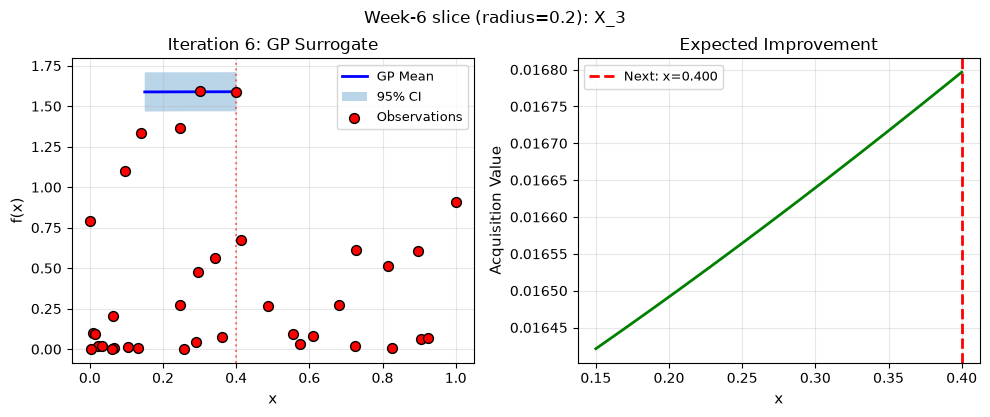

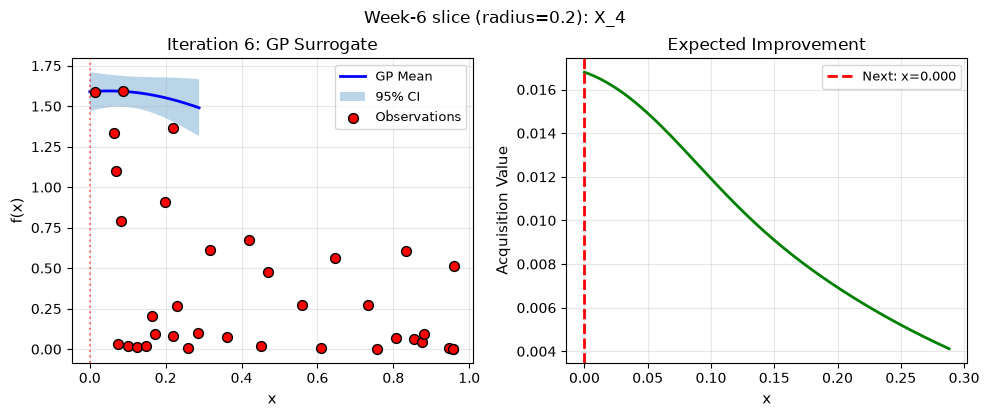

In [107]:
for d in [2, 3]:   # x3 (widened band) and x4
    lo, hi = local_bounds[d]
    grid = np.linspace(lo, hi, 200).reshape(-1, 1)
    Xg = np.tile(next_x, (len(grid), 1))
    Xg[:, d] = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std=True)
    ei_g = expected_improvement(mu_g, sigma_g, y_best, xi=XI)

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train=Y,
        X_test=grid, mu=mu_g, sigma=sigma_g,
        acquisition_values=ei_g, X_next=next_x[d],
        iteration=6, acq_name="Expected Improvement"
    )
    fig.suptitle(f"Week-6 slice (radius={RADIUS}): X_{d+1}", y=1.03)
    plt.show()

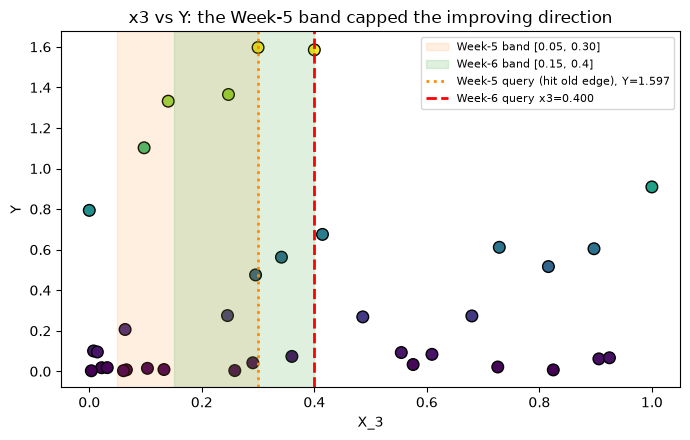

In [108]:
# x3 vs Y, showing the old band, the new band, and where the best point landed
plt.figure(figsize=(7, 4.5))
plt.scatter(X[:, 2], Y, c=Y, cmap="viridis", s=70, edgecolor="k")
plt.axvspan(0.05, 0.30, color="tab:orange", alpha=0.12, label="Week-5 band [0.05, 0.30]")
plt.axvspan(X3_LOW, X3_HIGH, color="tab:green", alpha=0.15, label=f"Week-6 band [{X3_LOW}, {X3_HIGH}]")
plt.axvline(0.300, color="darkorange", ls=":", lw=2, label="Week-5 query (hit old edge), Y=1.597")
plt.axvline(next_x[2], color="red", ls="--", lw=2, label=f"Week-6 query x3={next_x[2]:.3f}")
plt.xlabel("X_3"); plt.ylabel("Y")
plt.title("x3 vs Y: the Week-5 band capped the improving direction")
plt.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

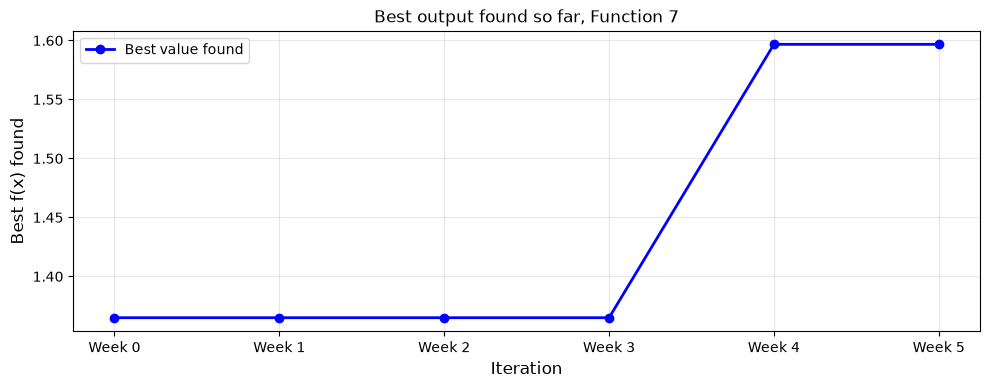

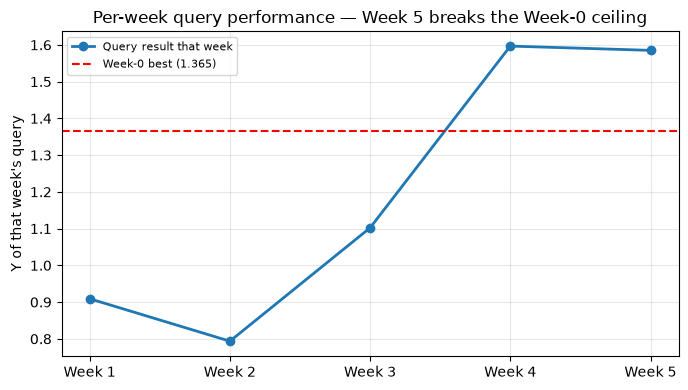

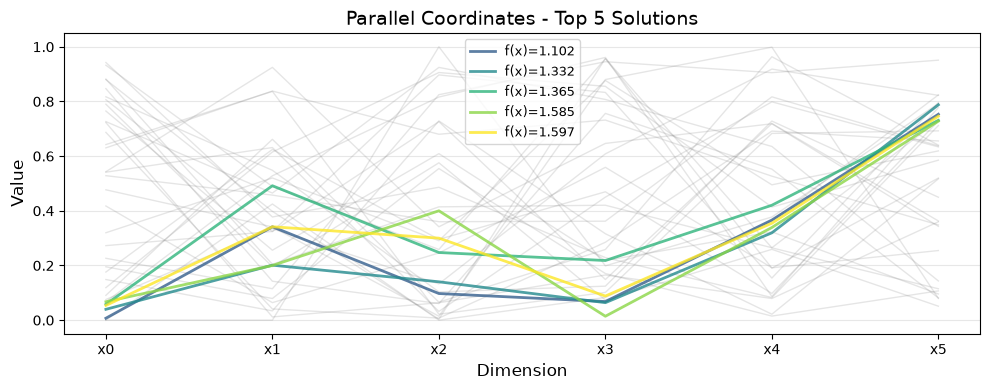

In [111]:
best_values = [Y[:-5].max(), Y[:-4].max(), Y[:-3].max(), Y[:-2].max(), Y[:-1].max(), Y.max()]
plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), ["Week 0", "Week 1", "Week 2", "Week 3", "Week 4", "Week 5"])
plt.title("Best output found so far, Function 7")
plt.show()

weekly = Y[-5:]   # robust: last five entries are Weeks 1-5, in order
plt.figure(figsize=(7, 4))
plt.plot(range(1, 6), weekly, "o-", lw=2, label="Query result that week")
plt.axhline(Y[:-5].max(), color="red", ls="--", label=f"Week-0 best ({Y[:-5].max():.3f})")
plt.xticks(range(1, 6), [f"Week {i}" for i in range(1, 6)])
plt.ylabel("Y of that week's query")
plt.title("Per-week query performance — Week 5 breaks the Week-0 ceiling")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Week 7: The x3 bracket is now closed

In [119]:
clean = (Y > 0.5) & (X[:, 0] < 0.3) & (X[:, 5] > 0.6)
idx = np.where(clean)[0]
idx = idx[np.argsort(X[idx, 2])]

print("x3 vs Y among CLEAN high performers (x1 < 0.3, x6 > 0.6):\n")
print(f"{'x3':>7}  {'Y':>8}   note")
for i in idx:
    note = ""
    if abs(X[i, 2] - 0.300) < 1e-3:
        note = "<-- Week 5, project best"
    elif abs(X[i, 2] - 0.400) < 1e-3:
        note = "<-- Week 6, Down from 0.300"
    print(f"{X[i,2]:7.3f}  {Y[i]:8.4f}   {note}")

x3 vs Y among CLEAN high performers (x1 < 0.3, x6 > 0.6):

     x3         Y   note
  0.000    0.7936   
  0.097    1.1021   
  0.140    1.3319   
  0.247    1.3650   
  0.300    1.5967   <-- Week 5, project best
  0.400    1.5851   <-- Week 6, Down from 0.300
  0.816    0.5165   
  0.897    0.6044   
  1.000    0.9091   


In [121]:
# --- Week 7: Interpolate the peak inside the bracket
# Three clean points bracket a maximum, so a quadratic through them estimates its location.
bx = np.array([0.247, 0.300, 0.400])
by = np.array([1.364968, 1.596708, 1.585074])
coef = np.polyfit(bx, by, 2)
x3_vertex = -coef[1] / (2 * coef[0])

print("Quadratic fit through the three bracket points:")
for xv, yv in zip(bx, by):
    print(f"  x3 = {xv:.3f}  ->  Y = {yv:.4f}")
print(f"\nEstimated peak location (vertex): x3 = {x3_vertex:.4f}")
print(f"Fitted Y at vertex              : {np.polyval(coef, x3_vertex):.4f}")

print("\nFitted curve across the bracket:")
for v in [0.28, 0.30, 0.32, 0.34, 0.35]:
    print(f"  x3 = {v:.2f}  ->  fitted Y = {np.polyval(coef, v):.4f}")

print("\nNote: this is an interpolation over three points, so the fitted Y is indicative only. The useful output is the peak LOCATION (~0.35), not the predicted height.")

Quadratic fit through the three bracket points:
  x3 = 0.247  ->  Y = 1.3650
  x3 = 0.300  ->  Y = 1.5967
  x3 = 0.400  ->  Y = 1.5851

Estimated peak location (vertex): x3 = 0.3480
Fitted Y at vertex              : 1.6644

Fitted curve across the bracket:
  x3 = 0.28  ->  fitted Y = 1.5286
  x3 = 0.30  ->  fitted Y = 1.5967
  x3 = 0.32  ->  fitted Y = 1.6413
  x3 = 0.34  ->  fitted Y = 1.6625
  x3 = 0.35  ->  fitted Y = 1.6642

Note: this is an interpolation over three points, so the fitted Y is indicative only. The useful output is the peak LOCATION (~0.35), not the predicted height.


### Locating the peak inside the bracket

Because the GP is indifferent along x3, it cannot tell us *where* in the bracket the peak sits - the EI surface is flat there. But three clean observations bracket a maximum, which is enough to interpolate one directly.

### What this means for the strategy

For two weeks the correct move was to **widen** - the data kept pointing outward and the model was under-confident. That is no longer true. The improvement direction has reversed, which changes the right action from exploration to **refinement inside a known bracket**.

Concretely for Week 7:
- **x3: [0.28, 0.36]**, centred on the interpolated vertex rather than chasing upward.
- **Radius: 0.12** (from 0.20). With the direction resolved and two results now within 0.012 of each other, the useful remaining gains are local. 
- This is the robustness/refinement stage the plan scheduled for Week 7, and it is now supported by evidence.

# Kernel Comparison and Calibration Check

In [125]:
DIM = 6

def make_gpr(kernel):
    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1e0))
    return GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=8, random_state=0)

kernel_options = {
    "RBF":              RBF(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1)),
    "Matern(nu = 2.5)": Matern(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1), nu=2.5),
}

kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls = []
    for tr_idx, te_idx in kf.split(X):
        gp_tmp = make_gpr(kern)
        gp_tmp.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = gp_tmp.predict(X[te_idx], return_std=True)
        sigma = np.maximum(sigma, 1e-6)
        ll = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((Y[te_idx] - mu)**2) / sigma**2
        lls.append(ll.mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:18s}: CV log-likelihood = {cv_scores[name]:+.3f}")

best_kernel_name = max(cv_scores, key=cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 7: {best_kernel_name}  (Matern has won every week)")

gp = make_gpr(chosen_kernel)
gp.fit(X, Y)

ls = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
print("\nLearned length-scales (short = influential):")
for i, l in enumerate(ls):
    flag = "  <-- GP indifferent" if l >= 9.99 else ""
    print(f"  x{i+1}: {l:.3f}{flag}")


  RBF               : CV log-likelihood = -9.734
  Matern(nu = 2.5)  : CV log-likelihood = -4.865

Selected kernel for Week 7: Matern(nu = 2.5)  (Matern has won every week)

Learned length-scales (short = influential):
  x1: 0.085
  x2: 10.000  <-- GP indifferent
  x3: 10.000  <-- GP indifferent
  x4: 0.825
  x5: 0.197
  x6: 0.146


In [131]:
# Week 7: Prediction-vs-actual calibration across all weeks
history = [("Week 2", Y_w2_new_point.item(), 1.4000), ("Week 4", Y_w4_new_point.item(), 1.5031),
           ("Week 5", Y_w5_new_point.item(), 1.4488), ("Week 6", Y_w6_new_point.item(), 1.6138)]

print(f"{'Week':>7}  {'predicted':>10}  {'actual':>9}  {'error':>9}")
for name, actual, pred in history:
    print(f"{name:>7}  {pred:10.4f}  {actual:9.4f}  {pred - actual:+9.4f}")

print("\nCalibration has improved substantially:")
print("  Weeks 2, 4 : over-predicted by ~0.40-0.49 (model badly optimistic)")
print("  Week 5     : under-predicted by 0.148 (opened-up region better than believed)")
print("  Week 6     : over-predicted by only 0.029 -- essentially calibrated")
print("\nA trustworthy surrogate is what makes tight local refinement sensible now.")

   Week   predicted     actual      error
 Week 2      1.4000     0.9091    +0.4909
 Week 4      1.5031     1.1021    +0.4010
 Week 5      1.4488     1.5967    -0.1479
 Week 6      1.6138     1.5851    +0.0287

Calibration has improved substantially:
  Weeks 2, 4 : over-predicted by ~0.40-0.49 (model badly optimistic)
  Week 5     : under-predicted by 0.148 (opened-up region better than believed)
  Week 6     : over-predicted by only 0.029 -- essentially calibrated

A trustworthy surrogate is what makes tight local refinement sensible now.


# Week 7: Leave-one-out robustness check

Before committing to a narrow search, checking if the surrogate's accuracy is not an artefact of one particular train/test split. Leave-one-out uses every point as a test case in turn.

In [138]:
loo = LeaveOneOut()
errors, z_scores = [], []
for tr_idx, te_idx in loo.split(X):
    g = make_gpr(chosen_kernel)
    g.fit(X[tr_idx], Y[tr_idx])
    mu, sd = g.predict(X[te_idx], return_std=True)
    sd = np.maximum(sd, 1e-6)
    errors.append(Y[te_idx][0] - mu[0])
    z_scores.append((Y[te_idx][0] - mu[0]) / sd[0])

errors, z_scores = np.array(errors), np.array(z_scores)
print(f"LOO mean absolute error : {np.abs(errors).mean():.4f}")
print(f"LOO RMSE                : {np.sqrt((errors**2).mean()):.4f}")
print(f"Mean |z-score|          : {np.abs(z_scores).mean():.3f}   (near 0.8 = well calibrated)")
print(f"Points with |z| > 2     : {(np.abs(z_scores) > 2).sum()} of {len(z_scores)}")

worst = np.argsort(np.abs(errors))[-3:][::-1]
print("\nLargest LOO errors (points the model finds hardest to predict):")
for i in worst:
    print(f"  Y={Y[i]:7.4f}  error={errors[i]:+7.4f}  x={np.round(X[i], 3)}")

LOO mean absolute error : 0.2556
LOO RMSE                : 0.3177
Mean |z-score|          : 1.355   (near 0.8 = well calibrated)
Points with |z| > 2     : 5 of 36

Largest LOO errors (points the model finds hardest to predict):
  Y= 0.0421  error=-0.8297  x=[0.32  0.52  0.291 0.877 0.495 0.619]
  Y= 0.0614  error=-0.8144  x=[0.119 0.615 0.906 0.855 0.414 0.585]
  Y= 0.5628  error=+0.4921  x=[0.543 0.925 0.342 0.646 0.718 0.343]


# Week: Bracketed refinement search

x3 narrowed to the bracket, x2 still set from evidence (the GP remains indifferent along it), radius tightened to 0.12.

In [141]:
RADIUS = 0.12                     # was 0.20 in Week 6
XI = 0.01
X3_LOW, X3_HIGH = 0.28, 0.36      # bracket, centred on the interpolated vertex (~0.348)
X2_LOW, X2_HIGH = 0.30, 0.39      # GP indifferent on x2; hold near the best point's 0.342

local_low  = np.clip(x_best - RADIUS, 0.0, 1.0)
local_high = np.clip(x_best + RADIUS, 0.0, 1.0)

# Evidence-set bands for the dimensions the GP treats as irrelevant (flat EI surface,
# so the optimiser would otherwise drift to an arbitrary bound).
local_low[1], local_high[1] = X2_LOW, X2_HIGH
local_low[2], local_high[2] = X3_LOW, X3_HIGH

local_bounds = list(zip(local_low, local_high))

print("Week-7 search box (tightened; centred on the project best):")
for i, (lo, hi) in enumerate(local_bounds):
    note = f"   <-- evidence-set (GP length-scale {ls[i]:.1f})" if i in (1, 2) else ""
    print(f"  x{i+1}: [{lo:.3f}, {hi:.3f}]{note}")


def expected_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.where(sigma < 1e-8, 0.0, ei)


def ei_fn(pts):
    mu, sigma = gp.predict(np.atleast_2d(pts), return_std=True)
    return expected_improvement(mu, sigma, y_best, xi=XI)


rng = np.random.default_rng(7)
cand = rng.uniform(local_low, local_high, size=(20000, DIM))
cand_ei = ei_fn(cand)
next_x = cand[np.argmax(cand_ei)]

starts = rng.uniform(local_low, local_high, size=(40, DIM))
best_val = -cand_ei.max()
for x0 in starts:
    res = minimize(lambda x: -ei_fn(x)[0], x0, method="L-BFGS-B", bounds=local_bounds)
    if res.fun < best_val:
        best_val, next_x = res.fun, res.x
next_x = np.clip(next_x, local_low, local_high)

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)
print(f"\nWeek 7 proposed point: {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   EI: {ei_fn(next_x)[0]:.4f}")
print(f"Current best to beat: {y_best:.4f}")
print(f"\nx3 = {next_x[2]:.3f}, against an interpolated vertex of {x3_vertex:.3f} -- the band")
print("is centred on the estimated peak rather than on a bracket edge.")
print(f"x2 = {next_x[1]:.3f}, held near the best point's 0.342 because the GP is flat there")
print("and two results 0.14 apart in x2 differed by only 0.012 in Y.")
print("\nThe model is now well calibrated (Week-6 error +0.029), so the predicted mean")
print("can be read as a reasonable estimate rather than discounted as in earlier weeks.")

Week-7 search box (tightened; centred on the project best):
  x1: [0.000, 0.174]
  x2: [0.300, 0.390]   <-- evidence-set (GP length-scale 10.0)
  x3: [0.280, 0.360]   <-- evidence-set (GP length-scale 10.0)
  x4: [0.000, 0.208]
  x5: [0.235, 0.475]
  x6: [0.626, 0.866]

Week 7 proposed point: [0.066356 0.39     0.36     0.       0.360831 0.75384 ]
Predicted mean: 1.5888   std: 0.0617   EI: 0.0167
Current best to beat: 1.5967

x3 = 0.360, against an interpolated vertex of 0.348 -- the band
is centred on the estimated peak rather than on a bracket edge.
x2 = 0.390, held near the best point's 0.342 because the GP is flat there
and two results 0.14 apart in x2 differed by only 0.012 in Y.

The model is now well calibrated (Week-6 error +0.029), so the predicted mean
can be read as a reasonable estimate rather than discounted as in earlier weeks.


# Week 7: Visualisation

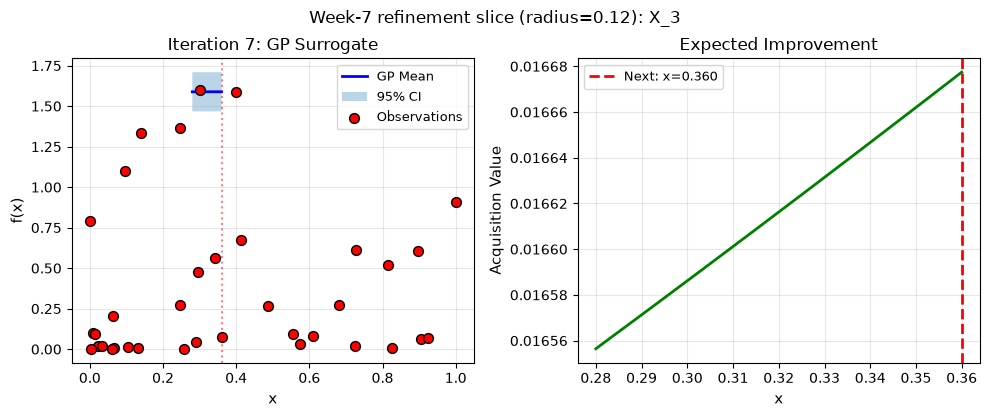

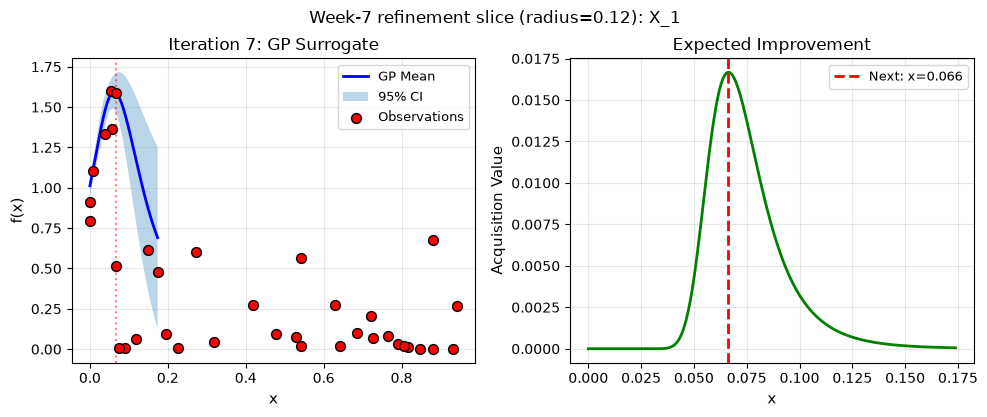

In [144]:
for d in [2, 0]:   # x3 (bracketed) and x1 (most influential per length-scale)
    lo, hi = local_bounds[d]
    grid = np.linspace(lo, hi, 200).reshape(-1, 1)
    Xg = np.tile(next_x, (len(grid), 1))
    Xg[:, d] = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std=True)
    ei_g = expected_improvement(mu_g, sigma_g, y_best, xi=XI)

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train=Y,
        X_test=grid, mu=mu_g, sigma=sigma_g,
        acquisition_values=ei_g, X_next=next_x[d],
        iteration=7, acq_name="Expected Improvement"
    )
    fig.suptitle(f"Week-7 refinement slice (radius={RADIUS}): X_{d+1}", y=1.03)
    plt.show()

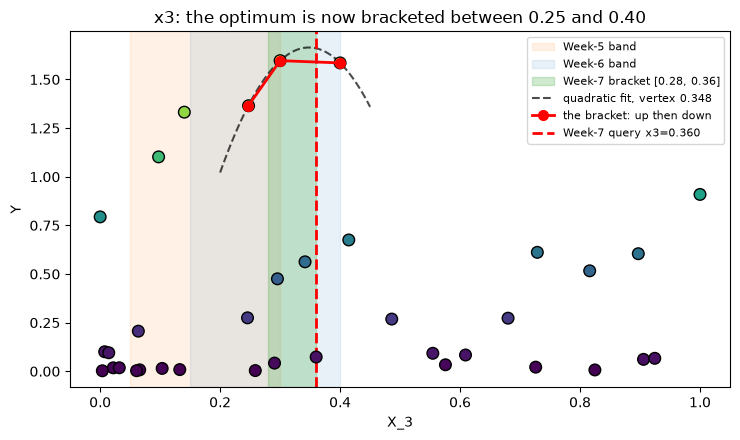

In [146]:
# x3 bracket: how the search window has evolved across weeks
plt.figure(figsize=(7.5, 4.5))
plt.scatter(X[:, 2], Y, c=Y, cmap="viridis", s=70, edgecolor="k", zorder=3)
plt.axvspan(0.05, 0.30, color="tab:orange", alpha=0.10, label="Week-5 band")
plt.axvspan(0.15, 0.40, color="tab:blue",   alpha=0.10, label="Week-6 band")
plt.axvspan(X3_LOW, X3_HIGH, color="tab:green", alpha=0.22, label=f"Week-7 bracket [{X3_LOW}, {X3_HIGH}]")
_xs = np.linspace(0.20, 0.45, 100)
plt.plot(_xs, np.polyval(coef, _xs), "k--", lw=1.5, alpha=0.7, label=f"quadratic fit, vertex {x3_vertex:.3f}")
plt.plot([0.247, 0.300, 0.400], [1.364968, 1.596708, 1.585074],
         "r.-", lw=2, ms=14, zorder=4, label="the bracket: up then down")
plt.axvline(next_x[2], color="red", ls="--", lw=2, label=f"Week-7 query x3={next_x[2]:.3f}")
plt.xlabel("X_3"); plt.ylabel("Y")
plt.title("x3: the optimum is now bracketed between 0.25 and 0.40")
plt.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

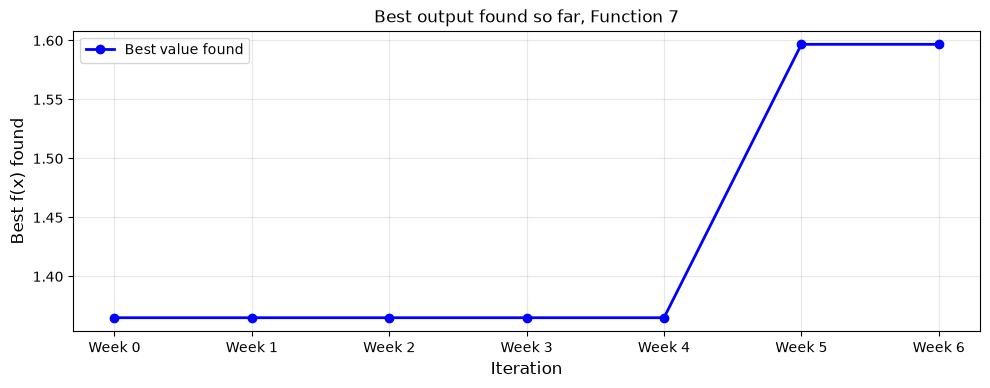

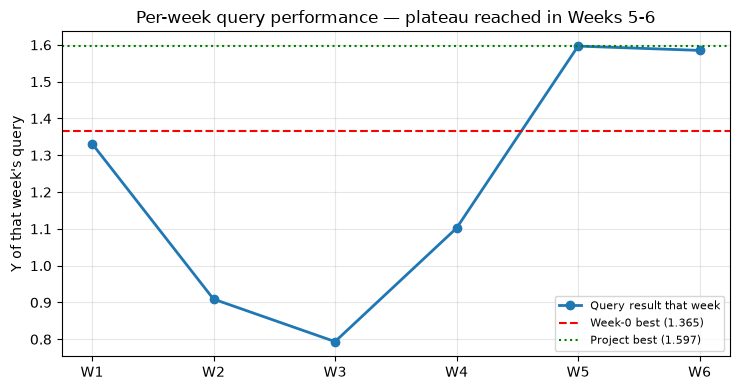

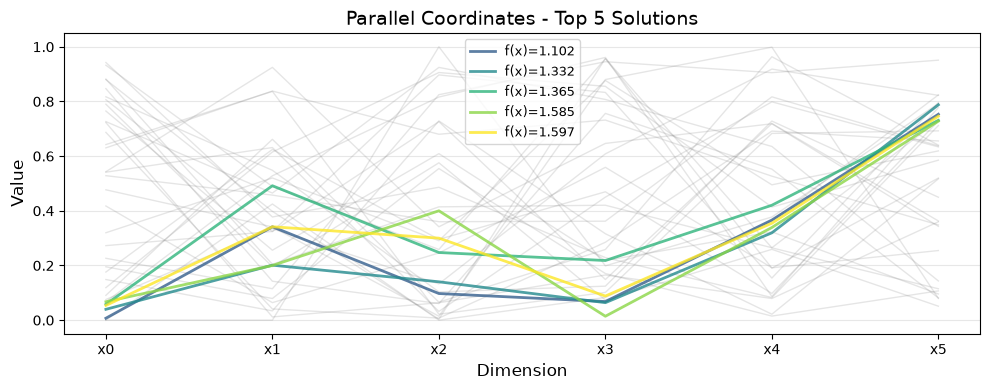

In [148]:
best_values = [Y[:-6].max(), Y[:-5].max(), Y[:-4].max(), Y[:-3].max(), Y[:-2].max(), Y[:-1].max(), Y.max()]
plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), [f"Week {i}" for i in range(7)])
plt.title("Best output found so far, Function 7")
plt.show()

weekly = Y[-6:]   # robust: last six entries are Weeks 1-6, in order
plt.figure(figsize=(7.5, 4))
plt.plot(range(1, 7), weekly, "o-", lw=2, label="Query result that week")
plt.axhline(Y[:-6].max(), color="red", ls="--", label=f"Week-0 best ({Y[:-6].max():.3f})")
plt.axhline(y_best, color="green", ls=":", label=f"Project best ({y_best:.3f})")
plt.xticks(range(1, 7), [f"W{i}" for i in range(1, 7)])
plt.ylabel("Y of that week's query")
plt.title("Per-week query performance — plateau reached in Weeks 5-6")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Portal Submission 

In [150]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(next_x)
print("Points to be submitted(Week 1):"  ,'0.039632-0.201121-0.140302-0.063997-0.319477-0.787730')
print("Points to be submitted(Week 2):"  ,'0.000000-0.000000-1.000000-0.198783-0.377305-0.792654')
print("Points to be submitted(Week 3):"  , "0.000000-0.424949-0.000000-0.083071-0.363094-0.823966")
print("Points to be submitted(Week 4):"  , "0.007106-0.341672-0.097422-0.068118-0.366155-0.753175")
print("Points to be submitted(Week 5):"  , "0.053813-0.341672-0.300000-0.088135-0.354691-0.745974")
print("Points to be submitted(Week 6):"  , "0.067403-0.200000-0.400000-0.014328-0.338968-0.727934")
print(f"Points to be submitted(Week 7): {submission_str}")

Points to be submitted(Week 1): 0.039632-0.201121-0.140302-0.063997-0.319477-0.787730
Points to be submitted(Week 2): 0.000000-0.000000-1.000000-0.198783-0.377305-0.792654
Points to be submitted(Week 3): 0.000000-0.424949-0.000000-0.083071-0.363094-0.823966
Points to be submitted(Week 4): 0.007106-0.341672-0.097422-0.068118-0.366155-0.753175
Points to be submitted(Week 5): 0.053813-0.341672-0.300000-0.088135-0.354691-0.745974
Points to be submitted(Week 6): 0.067403-0.200000-0.400000-0.014328-0.338968-0.727934
Points to be submitted(Week 7): 0.066356-0.390000-0.360000-0.000000-0.360831-0.753840
